<a href="https://colab.research.google.com/github/sultanjacob/Applied-Machine-Learning/blob/main/03_clustering/02_KMeans_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Unsupervised Learning (K-Means Clustering)

In this notebook, we take the clean master dataset generated in Phase 1 and apply K-Means clustering to discover hidden customer personas.

### Step 1: Loading & Scaling
K-Means groups data points by calculating the mathematical distance (Euclidean distance) between them. If we do not scale our features, variables with massive numbers (like `total_spend` in thousands of dollars) will completely overpower variables with small numbers (like `kids_encoded` which ranges from 0 to 3).

We use `StandardScaler` to force every column to have a mean of 0 and a standard deviation of 1, leveling the playing field.

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the uploaded file directly from session storage
df = pd.read_csv('master_customer_segments.csv')

# Drop household_id and non-numerical columns for scaling
household_ids = df['household_id']
numerical_features = df.select_dtypes(include=['int64', 'float64']).drop(columns=['household_id'], errors='ignore')

# Scale numerical columns so K-Means distance calculations are fair
scaler = StandardScaler()
scaled_features = scaler.fit_transform(numerical_features)

print(f"Success! Loaded {scaled_features.shape[0]} rows and {scaled_features.shape[1]} features ready for clustering.")

Success! Loaded 801 rows and 8 features ready for clustering.


### Step 2: Finding the Optimal "K" (How many clusters?)

In unsupervised learning, we don't know the "right" answer in advance. We have to figure out how many distinct customer personas (K) naturally exist in our data. To do this mathematically, we will test every K from 2 to 10 and evaluate the results using two standard industry metrics:

1. **The Elbow Method (Inertia):** This calculates the Within-Cluster Sum of Squares (WCSS). It measures how tightly grouped the clusters are. We plot the results and look for the "elbow" or hinge in the line; the point where adding more clusters stops significantly improving the tightness.

2. **The Silhouette Score:** This measures how similar a customer is to their own cluster compared to other clusters. The score ranges from -1 to 1. A higher score means the clusters are highly distinct and well-separated. We look for the absolute peak on this chart.

Calculating cluster metrics. This may take a few seconds...

K=2 | Inertia (Tightness): 5,083 | Silhouette Score (Separation): 0.2725
K=3 | Inertia (Tightness): 4,516 | Silhouette Score (Separation): 0.2009
K=4 | Inertia (Tightness): 4,081 | Silhouette Score (Separation): 0.1713
K=5 | Inertia (Tightness): 3,717 | Silhouette Score (Separation): 0.1547
K=6 | Inertia (Tightness): 3,412 | Silhouette Score (Separation): 0.1565
K=7 | Inertia (Tightness): 3,191 | Silhouette Score (Separation): 0.1589
K=8 | Inertia (Tightness): 3,024 | Silhouette Score (Separation): 0.1559
K=9 | Inertia (Tightness): 2,872 | Silhouette Score (Separation): 0.1650
K=10 | Inertia (Tightness): 2,728 | Silhouette Score (Separation): 0.1708


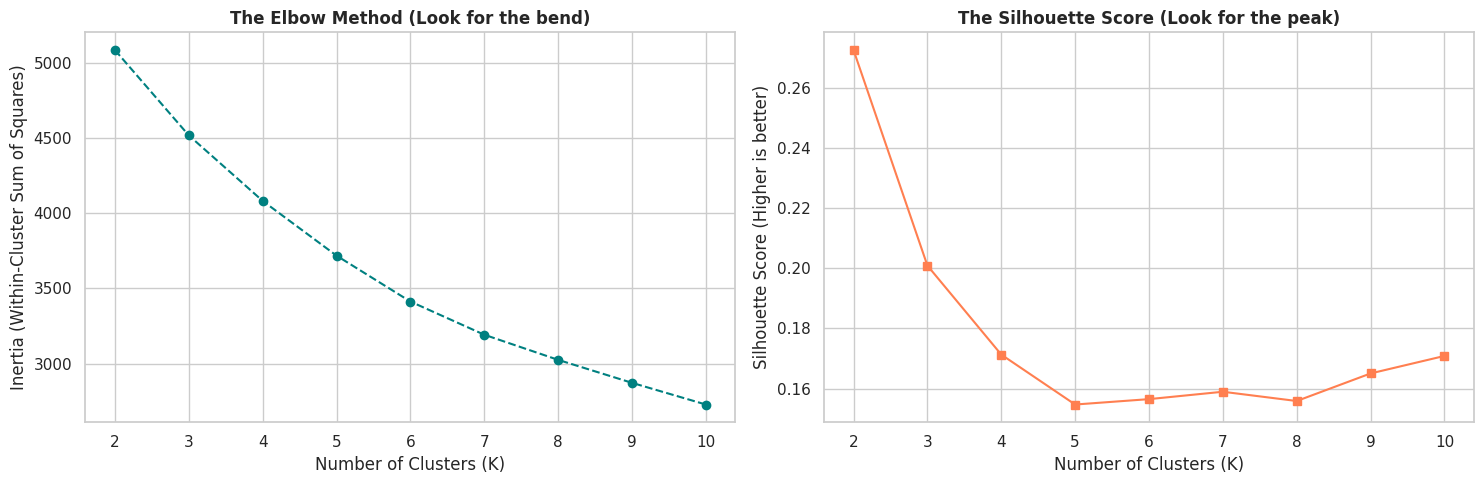

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean aesthetic for our graphs
sns.set_theme(style="whitegrid")

# Create empty lists to store the scores for each K
inertia_values = []
silhouette_scores = []

# We will test grouping the customers into anywhere from 2 to 10 segments
K_range = range(2, 11)

print("Calculating cluster metrics. This may take a few seconds...\n")

for k in K_range:
    # Initialize the algorithm (n_init=10 ensures it tries 10 different random starting points)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)

    # 1. Store the Inertia (for the Elbow Method)
    inertia_values.append(kmeans.inertia_)

    # 2. Store the Silhouette Score
    sil_score = silhouette_score(scaled_features, kmeans.labels_)
    silhouette_scores.append(sil_score)

    print(f"K={k} | Inertia (Tightness): {kmeans.inertia_:,.0f} | Silhouette Score (Separation): {sil_score:.4f}")

# --- VISUALIZING BOTH METHODS ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: The Elbow Method
axes[0].plot(K_range, inertia_values, marker='o', linestyle='--', color='teal')
axes[0].set_title('The Elbow Method (Look for the bend)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')

# Plot 2: The Silhouette Score
axes[1].plot(K_range, silhouette_scores, marker='s', linestyle='-', color='coral')
axes[1].set_title('The Silhouette Score (Look for the peak)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (Higher is better)')

plt.tight_layout()
plt.show()

# EXPLANATION FROM THE GRAPHS ABOVE

1. The Silhouette Score (The Peak)
Chart on the right: The absolute highest peak is clearly at K=2 (with a score of 0.2725). It takes a steep dive at K=3 and keeps dropping. If we were strictly following the Silhouette rule, the math says we should only have 2 clusters.

2. The Elbow Method (The Bend)
Chart on the left: We are looking for the spot where the line stops plunging downward and starts to flatten out. It is a fairly smooth curve, but the steepest drops happen early on, and it begins to smooth out slightly around K=3 or K=4.

### Step 3: Training the Final Model (K=3)

Based on the evaluation metrics, K=2 mathematically separates the data best, but K=3 provides a better balance of distinct mathematical separation and actionable business value (creating 3 distinct user personas instead of just a binary high/low split).

We will train the final K-Means model using `n_clusters=3`, extract the cluster labels, and map them back to our original, unscaled dataset so we can interpret the real-world dollar amounts and behaviors.

In [8]:
# 1. Initialize and train the final model with K=3
final_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
final_kmeans.fit(scaled_features)

# 2. Attach the cluster labels and the household_ids back to the original unscaled data
df['Cluster'] = final_kmeans.labels_
df['household_id'] = household_ids

# 3. Create a cluster profile by calculating the average of each feature per cluster
cluster_profiles = df.groupby('Cluster').agg(
    Household_Count=('household_id', 'count'),
    Avg_Total_Spend=('total_spend', 'mean'),
    Avg_Total_Trips=('total_transactions', 'mean'),
    Avg_Basket_Value=('avg_basket_value', 'mean'),
    Avg_Income_Encoded=('income_encoded', 'mean')
).round(2)

print("SUCCESS! Here are the 3 Hidden Customer Personas:\n")
display(cluster_profiles)

SUCCESS! Here are the 3 Hidden Customer Personas:



,Household_Count,Avg_Total_Spend,Avg_Total_Trips,Avg_Basket_Value,Avg_Income_Encoded
Cluster,,,,,
0,86,6554.59,228.99,36.20,5.23
1,484,1940.24,79.76,27.20,4.05
2,231,3843.90,66.11,63.31,5.90


#Cluster 0: The "Loyal Power Shoppers"
The Data: They are your smallest group (only 86 households), but their Avg_Total_Spend is a massive $6,554!

The Behavior: Look at their Avg_Total_Trips—nearly 229 trips. These people are practically living in the store. They don't have massive individual baskets ($36), but their sheer frequency makes them your most valuable demographic.

# Cluster 1: The "Everyday Budget Shoppers"
The Data: This is our largest segment by far (484 households), making up the core of the customer base.

The Behavior: They have the lowest Avg_Income_Encoded, the lowest overall spend ($1,940), and the smallest Avg_Basket_Value ($27.20). They come in relatively often (about 80 trips) but keep a tight leash on their wallets.

 # Cluster 2: The "Premium Bulk Buyers"
The Data: A solid mid-sized group (231 households) with the highest average income.

The Behavior: This group is fascinating. They have the lowest store visits (only 66 trips), but when they do show up, they drop serious cash. Their Avg_Basket_Value is nearly double the other groups at $63.31. They are stocking up or buying premium goods.


### Step 4: Visualizing the Customer Segments

Numbers in a table are great, but plotting the data visually proves that our K-Means algorithm successfully separated the households into distinct boundaries.

We will plot **Total Store Visits** against **Total Lifetime Spend** and map our three discovered personas to the clusters:
*   **Loyal Power Shoppers (Cluster 0):** High spend, incredibly high frequency.
*   **Everyday Budget Shoppers (Cluster 1):** Low spend, moderate frequency.
*   **Premium Bulk Buyers (Cluster 2):** High spend, low frequency.

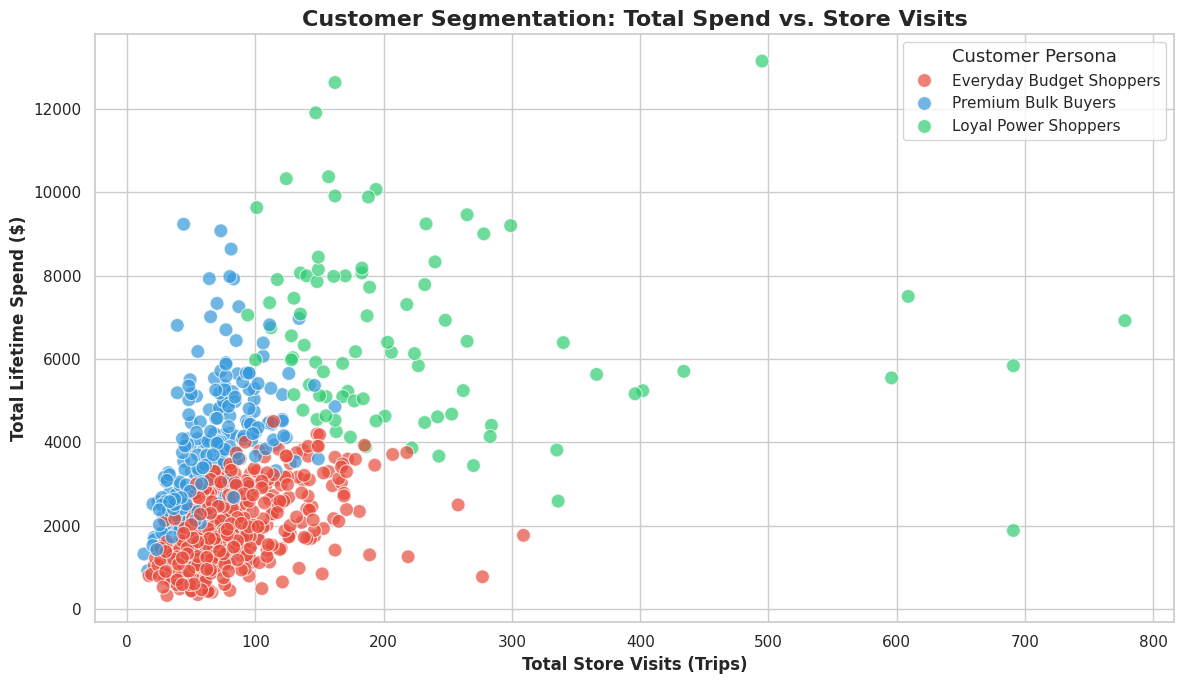

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map the mathematical cluster numbers to our business persona names
persona_map = {
    0: 'Loyal Power Shoppers',
    1: 'Everyday Budget Shoppers',
    2: 'Premium Bulk Buyers'
}
df['Persona'] = df['Cluster'].map(persona_map)

# 2. Set up the visualization canvas
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# 3. Create the scatter plot
sns.scatterplot(
    data=df,
    x='total_transactions',
    y='total_spend',
    hue='Persona',
    palette=['#e74c3c', '#3498db', '#2ecc71'], # Red, Blue, Green
    s=100,    # Size of the dots
    alpha=0.7 # Slight transparency to see overlapping points
)

# 4. Clean up the labels and aesthetics
plt.title('Customer Segmentation: Total Spend vs. Store Visits', fontsize=16, fontweight='bold')
plt.xlabel('Total Store Visits (Trips)', fontsize=12, fontweight='bold')
plt.ylabel('Total Lifetime Spend ($)', fontsize=12, fontweight='bold')
plt.legend(title='Customer Persona', title_fontsize='13', fontsize='11')

plt.tight_layout()
plt.show()

**The Green Extension (Power Shoppers):**
 You can physically see how these shoppers stretch all the way to the right side of the X-axis. They are visiting the store hundreds of times, driving up their lifetime spend through sheer loyalty.

**The Blue Spike (Bulk Buyers):** Notice how the blue dots shoot straight up the Y-axis while staying tightly packed on the left side of the X-axis? They don't visit often, but when they do, their baskets are massive.

**The Red Core (Budget Shoppers):** The dense cluster in the bottom left proves that the vast majority of the customer base makes frequent, low-cost trips.